
=== Top 12 subclusters by Clinical AD AUC ===
Subcluster  n_cells  mean_auc  auc_ci_lower  auc_ci_upper   fdr_q_value
      Ast1     4550  0.755444      0.750922      0.759967  0.000000e+00
      Oli3    10452  0.649469      0.585628      0.713311  0.000000e+00
      Ast3    34085  0.600863      0.578539      0.623187  0.000000e+00
      Oli1     7199  0.574599      0.497368      0.651829 4.619957e-153
       Ex4      310  0.569131      0.510666      0.627596  3.595062e-08
      Oli0     3365  0.562375      0.510663      0.614088  4.358149e-51
      Opc2     1597  0.556313      0.540363      0.572264  1.536530e-11
       Ex1    67445  0.555884      0.498928      0.612840  0.000000e+00
       Ex0   308320  0.555730      0.491319      0.620142  0.000000e+00
       In8    21843  0.553598      0.509367      0.597828  6.659413e-12
      Oli4    91139  0.552876      0.492678      0.613073  0.000000e+00
      Oli5    29909  0.552227      0.483490      0.620964 2.918719e-308

--- Top trajecto

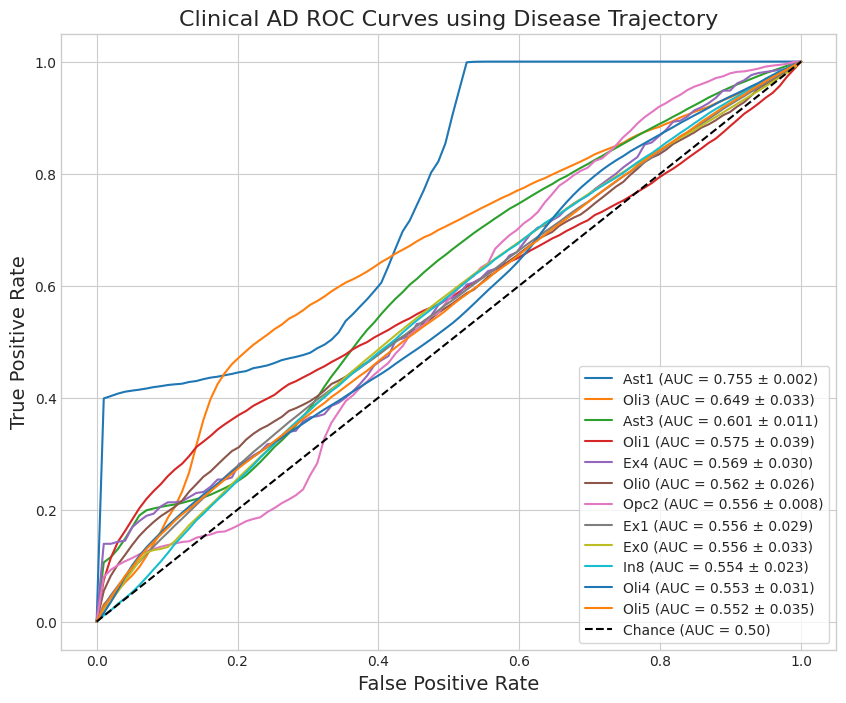

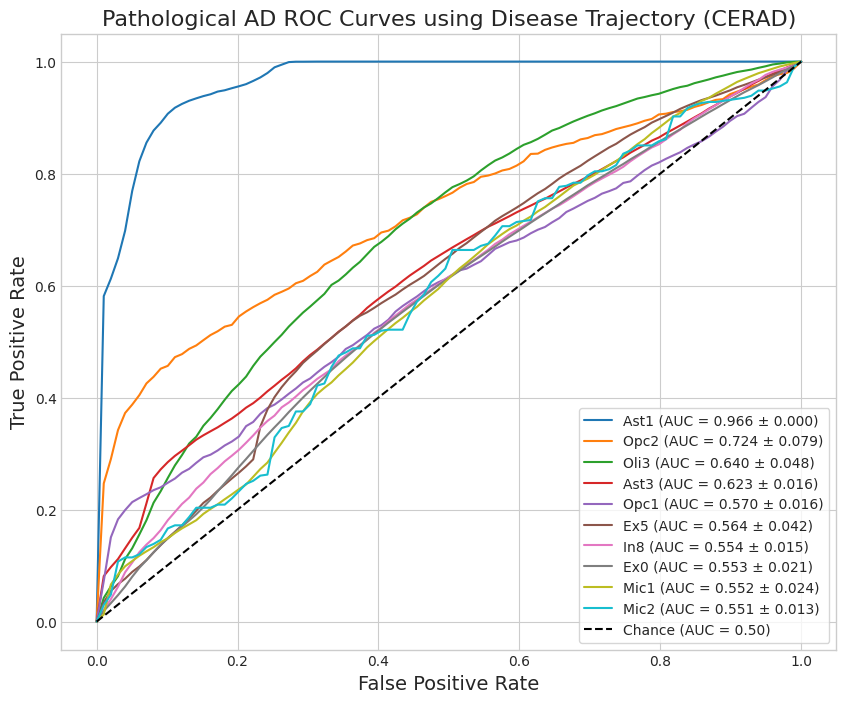

In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = '/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/seaad_pseudotime/pseudotime_centroid'
TOP_N = 12  # how many subclusters to print per category

# --- Load aggregated summary ---
df = pd.read_csv(os.path.join(RESULTS_DIR, 'publication_summary_statistics.csv'))

# --- Pseudotime gene list per subcluster (same definition as ml_triscope_seaad.ipynb:
#     split the `top_trajectory_genes` column on comma, take first 20) ---
df['top_trajectory_genes'] = df['top_trajectory_genes'].fillna('').apply(
    lambda x: [g.strip() for g in x.split(',') if g.strip()]
)

# --- Top subclusters per category ---
def show_top(df, auc_col, ci_lo, ci_hi, q_col, label):
    cols = ['Subcluster', 'n_cells', auc_col, ci_lo, ci_hi, q_col]
    top = df.sort_values(auc_col, ascending=False).head(TOP_N).reset_index(drop=True)
    print(f'\n=== Top {TOP_N} subclusters by {label} AUC ===')
    print(top[cols].to_string(index=False))
    print(f'\n--- Top trajectory-influencing genes per subcluster ({label}) ---')
    for _, row in top.iterrows():
        genes = row['top_trajectory_genes'][:20]
        print(f"{row['Subcluster']:>6}: {', '.join(genes) if genes else '(none)'}")
    return top

_ = show_top(df, 'mean_auc',       'auc_ci_lower',    'auc_ci_upper',    'fdr_q_value',       'Clinical AD')
_ = show_top(df, 'mean_auc_cerad', 'auc_cerad_lower', 'auc_cerad_upper', 'fdr_q_value_cerad', 'CERAD (neuropathology)')

# --- Combined ROC plot helper (reads the npz files written by pseudotime_seaad_centroid.py) ---
plt.style.use('seaborn-v0_8-whitegrid')

def plot_combined_roc(pattern, title):
    files = sorted(glob.glob(os.path.join(RESULTS_DIR, pattern)))
    if not files:
        print(f'[skip] no files match {pattern}')
        return
    entries = []
    for fp in files:
        d = np.load(fp, allow_pickle=True)
        entries.append({
            'fpr': d['fpr'],
            'tpr': d['tpr'],
            'mean_auc': float(d['mean_auc']),
            'se_auc': float(d['se_auc']),
            'Subcluster': re.sub(r'^roc_(clinical|cerad)_|\.npz$', '', os.path.basename(fp)),
        })
    entries.sort(key=lambda x: x['mean_auc'], reverse=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    for e in entries:
        ax.plot(e['fpr'], e['tpr'],
                label=f"{e['Subcluster']} (AUC = {e['mean_auc']:.3f} ± {e['se_auc']:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    ax.set_xlabel('False Positive Rate', fontsize=14)
    ax.set_ylabel('True Positive Rate', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='lower right', frameon=True, fontsize=10)
    plt.show()

plot_combined_roc('roc_clinical_*.npz', 'Clinical AD ROC Curves using Disease Trajectory')
plot_combined_roc('roc_cerad_*.npz',    'Pathological AD ROC Curves using Disease Trajectory (CERAD)')
